In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, average_precision_score, PrecisionRecallDisplay, precision_recall_curve
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

### Load data

In [3]:
df2 = pd.read_csv(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.csv") #Local
df2.head(2)

,child_age,child_weight,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,wealth_index,malnurished,province_1.0,province_2.0,province_3.0,province_4.0,province_5.0,province_6.0,province_7.0
0,1,-1.085628,0,0,0,1,5,0,1,1,1,0,0,0,0,0,0
1,3,0.420314,0,1,0,1,5,0,1,1,1,0,0,0,0,0,0


### Train-test split

In [4]:
X = df2.drop(columns=['malnurished'])
y = df2['malnurished']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state=42)

# Decision Tree

## Simple mode

In [28]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [7]:
y_pred = dt.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.68      0.69       707
           1       0.62      0.64      0.63       579

    accuracy                           0.66      1286
   macro avg       0.66      0.66      0.66      1286
weighted avg       0.66      0.66      0.66      1286



### Average Precision Score

In [8]:
y_probas = dt.predict_proba(X_test)[:, 1]
print(f'Average Precision: {average_precision_score(y_test, y_probas)}')

Average Precision: 0.5607681150390782


# Hyperparameter Tuning

In [9]:
params = {
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

dt_params = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=dt_params,
    param_grid=params,
    scoring='recall',        
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 90 candidates, totalling 450 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 10, 15, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='recall', verbose=1)

In [10]:

print("Best Parameters:", grid_search.best_params_)
print("Best CV Recall:", grid_search.best_score_)

Best Parameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Recall: 0.7234043345497878


In [11]:
dt_tune = grid_search.best_estimator_
y_pred = dt_tune.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.42      0.56       707
           1       0.55      0.87      0.68       579

    accuracy                           0.63      1286
   macro avg       0.68      0.65      0.62      1286
weighted avg       0.69      0.63      0.61      1286



### Average precision

In [12]:
y_probas_tune = dt_tune.predict_proba(X_test)[:, 1]
print(f'Average Precision: {average_precision_score(y_test, y_probas_tune)}')

Average Precision: 0.6000392630355735


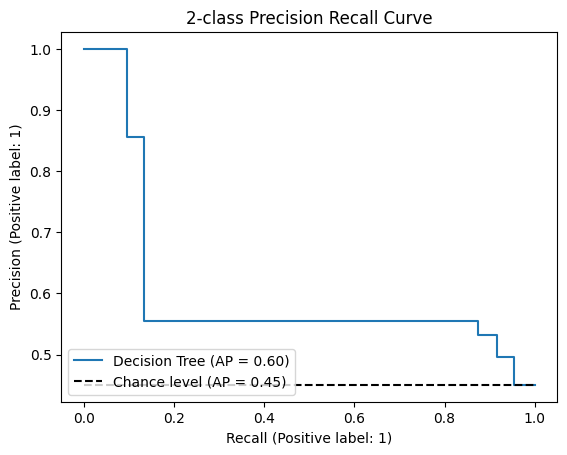

In [14]:
display = PrecisionRecallDisplay.from_estimator(
    dt_tune,
    X_test,
    y_test, 
    name="Decision Tree",
    plot_chance_level = True,
)
display.ax_.set_title('2-class Precision Recall Curve')
plt.show()

### Confusion matrix

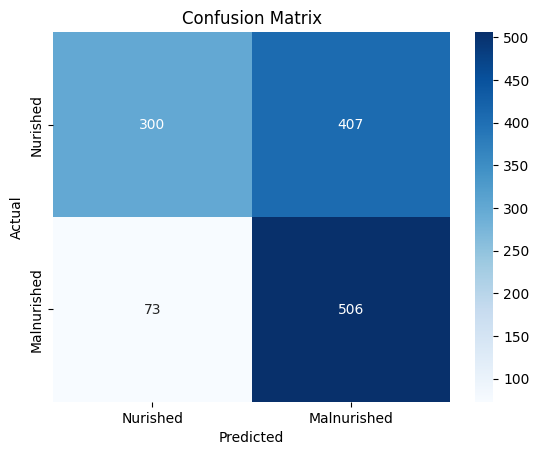

In [15]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Nurished', 'Malnurished'], yticklabels=['Nurished', 'Malnurished'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [21]:
# Get feature importances in simple model
feature_importance = dt.feature_importances_
feature_names = X_train.columns

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

# Display
print(importance_df)

                   Feature  Importance
1             child_weight    0.398567
0                child_age    0.140233
8             wealth_index    0.098492
6         mother_education    0.082285
5                child_sex    0.042432
4                     area    0.038280
3       fever_last_2_weeks    0.034822
10            province_2.0    0.024019
2   diarrhoea_last_2_weeks    0.021007
14            province_6.0    0.020319
15            province_7.0    0.020026
11            province_3.0    0.018471
12            province_4.0    0.018419
13            province_5.0    0.018124
9             province_1.0    0.012800
7         health_insurance    0.011706


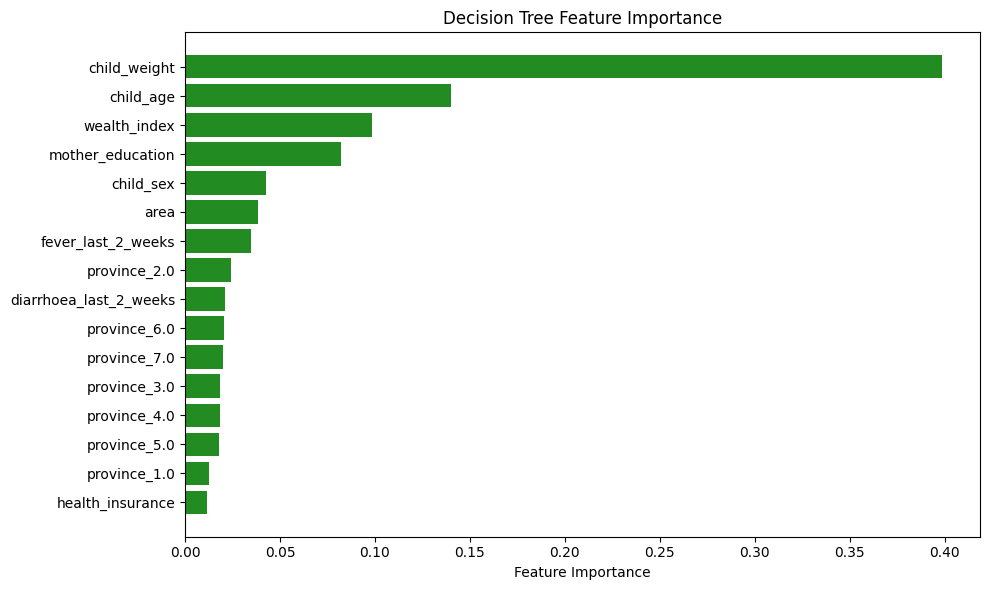

In [22]:
# Bar plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='forestgreen')
plt.xlabel("Feature Importance")
plt.title("Decision Tree Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [19]:
# Get feature importances in tuned model
feature_importance = dt_tune.feature_importances_
feature_names = X_train.columns

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

# Display
print(importance_df)

                   Feature  Importance
1             child_weight    0.709834
0                child_age    0.290166
2   diarrhoea_last_2_weeks    0.000000
3       fever_last_2_weeks    0.000000
4                     area    0.000000
5                child_sex    0.000000
6         mother_education    0.000000
7         health_insurance    0.000000
8             wealth_index    0.000000
9             province_1.0    0.000000
10            province_2.0    0.000000
11            province_3.0    0.000000
12            province_4.0    0.000000
13            province_5.0    0.000000
14            province_6.0    0.000000
15            province_7.0    0.000000


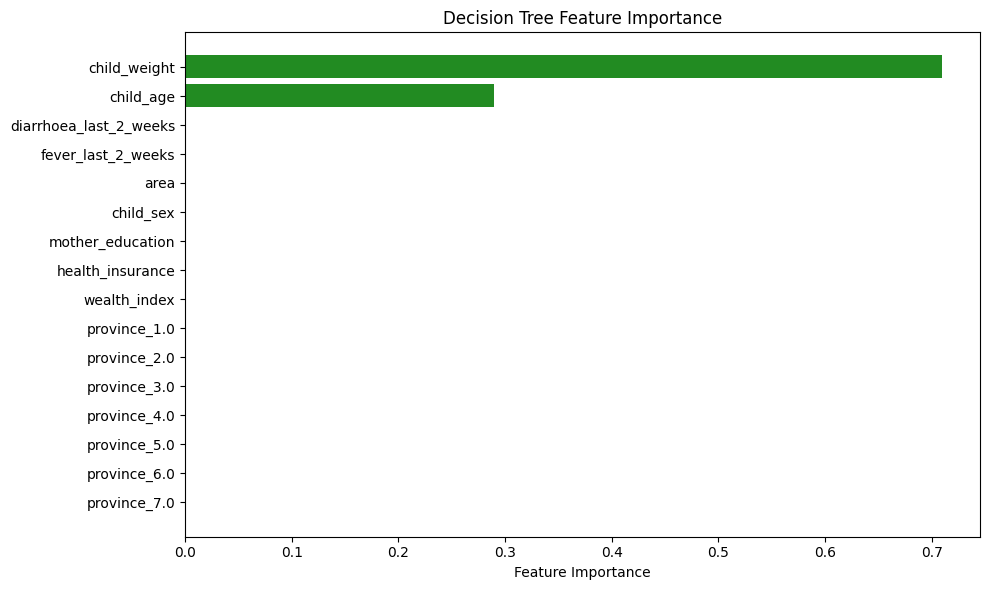

In [20]:
# Bar plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='forestgreen')
plt.xlabel("Feature Importance")
plt.title("Decision Tree Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


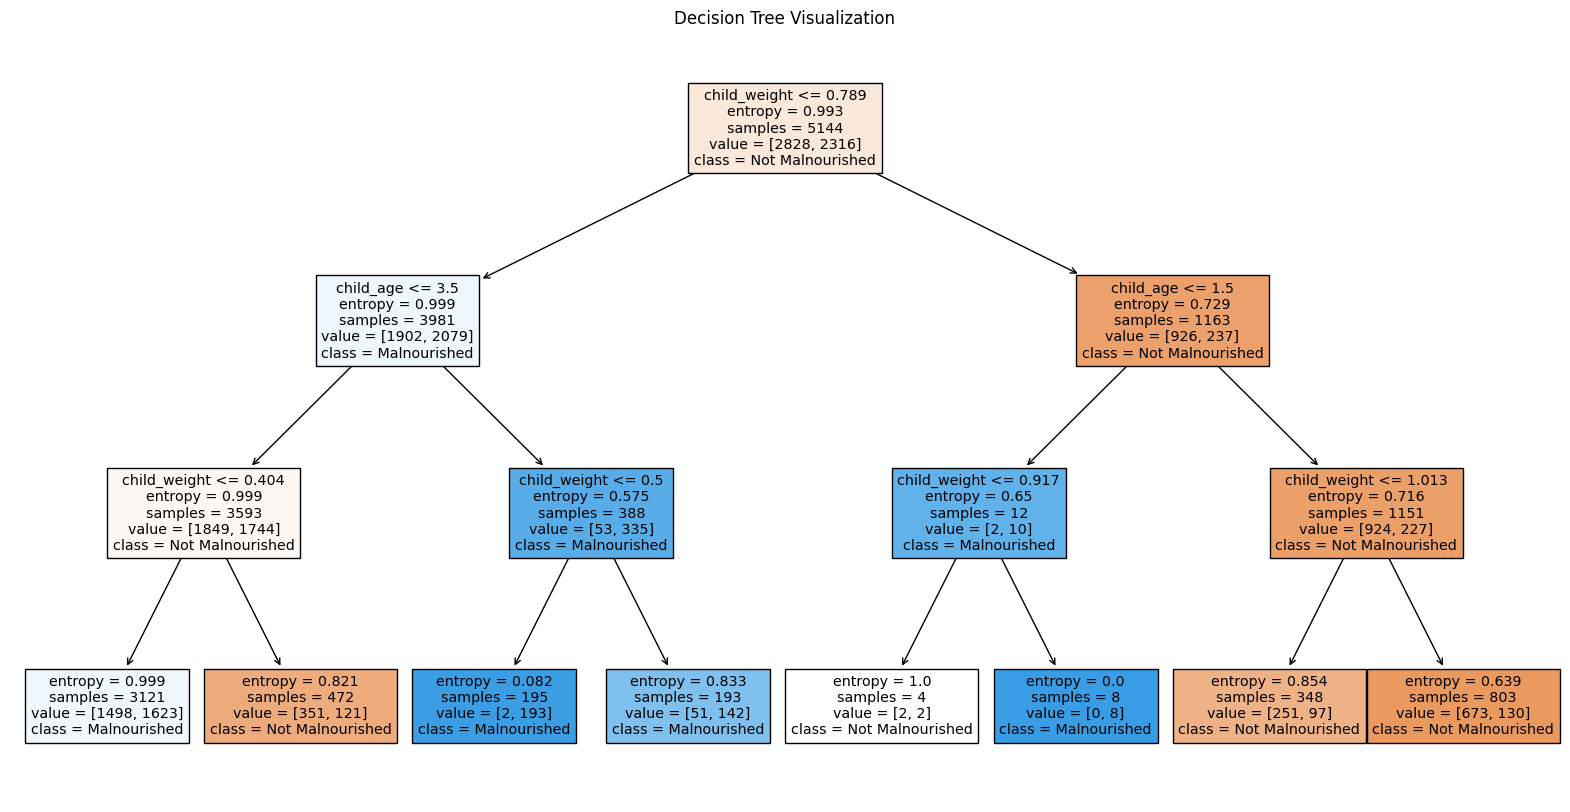

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(dt_tune, feature_names=X.columns, class_names=['Not Malnourished', 'Malnourished'], filled=True)
plt.title("Decision Tree Visualization")
plt.show()


## Additional

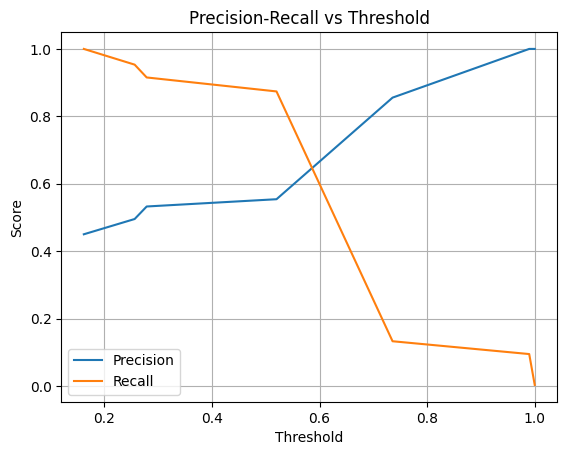

In [27]:
y_probas = dt_tune.predict_proba(X_test)[:, 1]       #Probabilities for class 1
precision, recall, thresholds = precision_recall_curve(y_test, y_probas)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.grid()
plt.legend()
plt.show()

In [28]:
# Apply custom threshold
y_probas_custom = (y_probas >= 0.40).astype(int)
print(f'Classification Report: \n{classification_report(y_test, y_probas_custom)}\n')

Classification Report: 
              precision    recall  f1-score   support

           0       0.80      0.42      0.56       707
           1       0.55      0.87      0.68       579

    accuracy                           0.63      1286
   macro avg       0.68      0.65      0.62      1286
weighted avg       0.69      0.63      0.61      1286


